In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings

warnings.filterwarnings('ignore')

print("=== BÀI 4: PHÂN CỤM DỮ LIỆU (CLUSTERING) TRÊN D1 & D2 ===\n")

try:
    # ==========================================
    # PHẦN 1: PHÂN CỤM TRÊN BỘ D1 (UCI CREDIT)
    # ==========================================
    print("[1] Đang xử lý bộ dữ liệu D1 (UCI Credit)...")
    df1 = pd.read_csv('UCI_Credit_Card.csv').sample(n=5000, random_state=42)

    # Tiền xử lý D1 (Chỉ lấy các cột đặc trưng chính, bỏ cột ID và Target)
    X1 = df1[['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']]
    scaler1 = StandardScaler()
    X1_scaled = scaler1.fit_transform(X1)

    # Thuật toán 1: K-Means trên D1 (Chọn k=3 giả định sau khi check Elbow)
    kmeans_d1 = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_kmeans_d1 = kmeans_d1.fit_predict(X1_scaled)

    # Thuật toán 2: Agglomerative Clustering trên D1
    agglo_d1 = AgglomerativeClustering(n_clusters=3)
    labels_agglo_d1 = agglo_d1.fit_predict(X1_scaled)

    # Đánh giá D1
    print("-> Đánh giá mô hình trên D1:")
    print(f"   K-Means       - Silhouette: {silhouette_score(X1_scaled, labels_kmeans_d1):.4f} | Davies-Bouldin: {davies_bouldin_score(X1_scaled, labels_kmeans_d1):.4f}")
    print(f"   Agglomerative - Silhouette: {silhouette_score(X1_scaled, labels_agglo_d1):.4f} | Davies-Bouldin: {davies_bouldin_score(X1_scaled, labels_agglo_d1):.4f}")


    # ==========================================
    # PHẦN 2: PHÂN CỤM TRÊN BỘ D2 (HOTEL BOOKINGS)
    # ==========================================
    print("\n" + "="*50)
    print("\n[2] Đang xử lý bộ dữ liệu D2 (Hotel Bookings)...")
    df2 = pd.read_csv('hotel_bookings.csv').sample(n=5000, random_state=42)

    # Tiền xử lý D2: Chọn lọc thuộc tính số và hạng mục
    features2_num = ['lead_time', 'adr', 'total_of_special_requests']
    features2_cat = ['customer_type', 'meal']
    X2 = df2[features2_num + features2_cat].dropna()

    # ColumnTransformer để Chuẩn hóa số và Mã hóa hạng mục
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), features2_num),
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), features2_cat)
        ])
    X2_scaled = preprocessor.fit_transform(X2)

    # Thuật toán 1: K-Means trên D2 (k=3)
    kmeans_d2 = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_kmeans_d2 = kmeans_d2.fit_predict(X2_scaled)

    # Thuật toán 2: Agglomerative Clustering trên D2
    agglo_d2 = AgglomerativeClustering(n_clusters=3)
    labels_agglo_d2 = agglo_d2.fit_predict(X2_scaled)

    # Đánh giá D2
    print("-> Đánh giá mô hình trên D2:")
    print(f"   K-Means       - Silhouette: {silhouette_score(X2_scaled, labels_kmeans_d2):.4f} | Davies-Bouldin: {davies_bouldin_score(X2_scaled, labels_kmeans_d2):.4f}")
    print(f"   Agglomerative - Silhouette: {silhouette_score(X2_scaled, labels_agglo_d2):.4f} | Davies-Bouldin: {davies_bouldin_score(X2_scaled, labels_agglo_d2):.4f}")

except FileNotFoundError as e:
    print(f"LỖI: Không tìm thấy file. Chi tiết: {e}")
except Exception as e:
    print(f"LỖI HỆ THỐNG: {e}")

=== BÀI 4: PHÂN CỤM DỮ LIỆU (CLUSTERING) TRÊN D1 & D2 ===

[1] Đang xử lý bộ dữ liệu D1 (UCI Credit)...
-> Đánh giá mô hình trên D1:
   K-Means       - Silhouette: 0.2909 | Davies-Bouldin: 1.3246
   Agglomerative - Silhouette: 0.4375 | Davies-Bouldin: 0.8839


[2] Đang xử lý bộ dữ liệu D2 (Hotel Bookings)...
-> Đánh giá mô hình trên D2:
   K-Means       - Silhouette: 0.2486 | Davies-Bouldin: 1.4328
   Agglomerative - Silhouette: 0.1802 | Davies-Bouldin: 1.6477


=== TÌM SỐ CỤM TỐI ƯU (ELBOW METHOD) ===


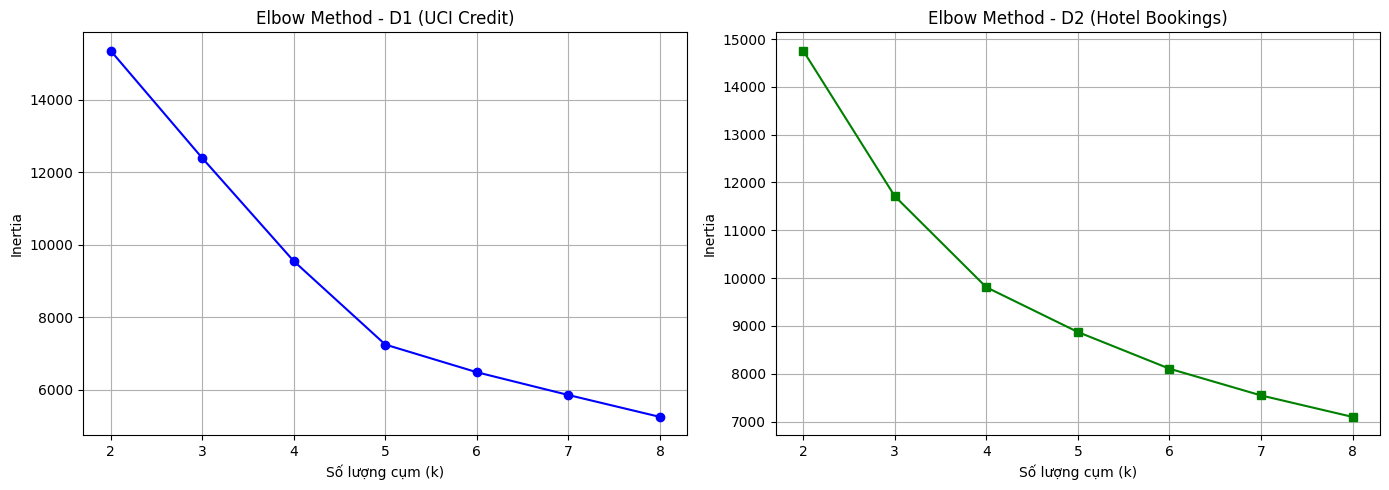

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("=== TÌM SỐ CỤM TỐI ƯU (ELBOW METHOD) ===")

# Tính toán giá trị Inertia (Tổng bình phương khoảng cách trong cụm) cho k từ 2 đến 8
k_values = range(2, 9)
inertia_d1 = []
inertia_d2 = []

# Chạy vòng lặp thử nghiệm k trên D1
for k in k_values:
    kmeans_1 = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_1.fit(X1_scaled) # X1_scaled đã có từ ô code trước
    inertia_d1.append(kmeans_1.inertia_)

# Chạy vòng lặp thử nghiệm k trên D2
for k in k_values:
    kmeans_2 = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_2.fit(X2_scaled) # X2_scaled đã có từ ô code trước
    inertia_d2.append(kmeans_2.inertia_)

# Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ D1
ax1.plot(k_values, inertia_d1, marker='o', linestyle='-', color='b')
ax1.set_title('Elbow Method - D1 (UCI Credit)')
ax1.set_xlabel('Số lượng cụm (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True)

# Biểu đồ D2
ax2.plot(k_values, inertia_d2, marker='s', linestyle='-', color='g')
ax2.set_title('Elbow Method - D2 (Hotel Bookings)')
ax2.set_xlabel('Số lượng cụm (k)')
ax2.set_ylabel('Inertia')
ax2.grid(True)

plt.tight_layout()
plt.show()